# 4. What should the pass do with a value that is missing or cannot be read, so that no decision invents or deletes a fact?

**Week 1, Wednesday. Chapter 4 of 6.** The pass is the chain of steps that turns the raw export from the ERP, the enterprise resource
planning system Finance books orders in, into a clean file. Chapter 1's profile, a count of the
values each field holds, found one row with no status and one amount that does not convert.
Chapter 3 built the pass's first step, the identity rule: one row per `order_id`, keeping the copy
whose amount converts and the first when both do. It kept 186 orders and set 15 rows aside with a
reason each, which puts Q1 at Rs 1,90,00,000, level with the books, Finance's own record of Q1, to
the rupee. This chapter decides each missing and unreadable value that is left, and writes the
reason down.

> **The client asks.** "Your dashboard says Q1 was Rs 2.1 crore. Our books say 1.9. Until your
> numbers match ours, Finance will not act on a drop measured from an ERP export. Send me a
> reconciliation."
>
> Anand Iyer, finance controller, Kalpa Retail

**Who needs the answer.** Operations reads the delivered share, the share of orders whose status says delivered, every week,
and Finance reads every rupee. A default invents a delivery nobody recorded, a zero invents an order
sold for nothing, and a drop deletes an order Finance has booked. Anand Iyer's analyst, who ties out
every figure tonight by matching it to the books line by line, reads every choice in the log the
pass writes.

**The questions on the way.**

1. What could the pass do with a missing status or an unreadable amount, and what does each choice claim?
2. What happens to the order with no status?
3. Is a missing discount a zero?
4. What if every failure is turned into zero?
5. Where can an unreadable amount be repaired from?
6. Do the profile and the logs agree on every defect?

**The need.** The metrics at stake are the delivered share of Q2 orders, Q2 revenue at
Rs 1,87,00,000 and Q1 against the books. The 186 kept orders still carry two kinds of defect. One
order has no status. Fifty-five orders have no discount, which Tuesday met. And the pass needs a
policy for any amount that does not convert, because the next export will carry one without a
twin, a second row of the same order that carries the value.

**Who else faces it.** On the evening of Friday 12 December 2014 a fault in Repricer Express, a tool that third-party sellers on Amazon's UK Marketplace used to set their prices, priced hundreds of items at 1p for about an hour; Amazon said most orders were cancelled once the error was spotted (BBC News, 15 December 2014, checked 30 Sep 2026). Nothing questioned the wrong price before orders were placed against real stock, and nothing questions a coerced zero in a report either.

For more depth on the business behind these numbers, the retail dossier,
`content/W01/D1/study-notes/C2_W01_D01_domain_retail_STUDENT.md`, covers how the business makes money
in section 3, who decides what in section 4, and in section 5 the revenue tree, which writes revenue as
customers x orders per customer x revenue per order.

**Setup.** The cell loads the shared helper `kit` and the tools so far. `read_orders()` reads each
row into a dictionary of text with its file line, `convert()` turns an amount into rupees or says
why it could not, `profile()` counts each field's present, convertible and distinct values, as in
chapter 1, and `identity_rule()` keeps one row per `order_id` and logs every row it sets aside, as
chapter 3 built it. Conversion follows the rule: every kept amount is converted, and any that fails
goes to a rejects log with its line and reason. That is the pass's order for the rest of the day,
the identity rule first and conversion after it.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit

import csv, json, math
from collections import Counter
from datetime import date

DATA = kit.data_dir()
ORDERS_CSV = DATA / "C2_W01_D03_orders_STUDENT.csv"
BOOKS_Q1 = 19000000        # Anand's Q1 to the rupee, which his analyst sends on request

def read_orders(path=ORDERS_CSV):
    """Every row of an export as a dictionary of text, with the file line it came from."""
    with open(path, newline="", encoding="utf-8") as f:
        return [dict(row, line=n) for n, row in enumerate(csv.DictReader(f), start=2)]

def convert(value):
    """A whole number of rupees, or None with the reason, so a failure is counted, never hidden."""
    try:
        return int(value), ""
    except (TypeError, ValueError):
        return None, "amount does not convert to a whole number"

def Q(rows, quarter):
    """Rupees in a quarter over the amounts that convert."""
    return sum(convert(r["amount"])[0] or 0 for r in rows if r["quarter"] == quarter)

FIELDS = ["order_id", "customer_id", "segment", "channel", "city", "order_date", "amount",
          "status", "quarter", "discount"]
NUMERIC = {"amount", "discount"}

def profile(rows, fields=FIELDS):
    """Per field: present, convertible where the field is a number, and distinct."""
    out = {}
    for f in fields:
        present = [r.get(f, "") for r in rows if r.get(f, "") not in ("", None)]
        ok = [v for v in present if convert(v)[0] is not None] if f in NUMERIC else present
        out[f] = {"present": len(present), "convertible": len(ok), "distinct": len(set(present))}
    return out

def identity_rule(rows, key="order_id"):
    """One row per order: the first copy whose amount converts stays, and every other row is logged."""
    groups = {}
    for r in rows:
        groups.setdefault(r[key], []).append(r)
    kept, log = [], []
    for k, rs in groups.items():
        valid = [r for r in rs if convert(r["amount"])[0] is not None]
        keep = (valid or rs)[0]
        kept.append(keep)
        for r in rs:
            if r is keep:
                continue
            differs = [f for f in r if f != "line" and r[f] != keep[f]]
            reason = ("copy whose amount does not convert; its twin carries the value"
                      if convert(r["amount"])[0] is None else "second copy of the order")
            if differs and "amount" not in differs:
                reason += "; differs on " + ", ".join(differs)
            log.append({"line": r["line"], "order_id": k, "quarter": r["quarter"], "segment": r["segment"],
                        "amount": r["amount"], "rule": key, "reason": reason, "kept_line": keep["line"]})
    return kept, log

raw = read_orders()
kept, set_aside = identity_rule(raw)
clean, rejects = [], []
for r in kept:
    value, reason = convert(r["amount"])
    if value is None:
        rejects.append({"line": r["line"], "order_id": r["order_id"], "field": "amount", "reason": reason})
    else:
        clean.append(dict(r, amount=value))
print(len(clean), "orders kept;", len(set_aside), "rows set aside;", len(rejects), "in the rejects log")

186 orders kept; 15 rows set aside; 0 in the rejects log


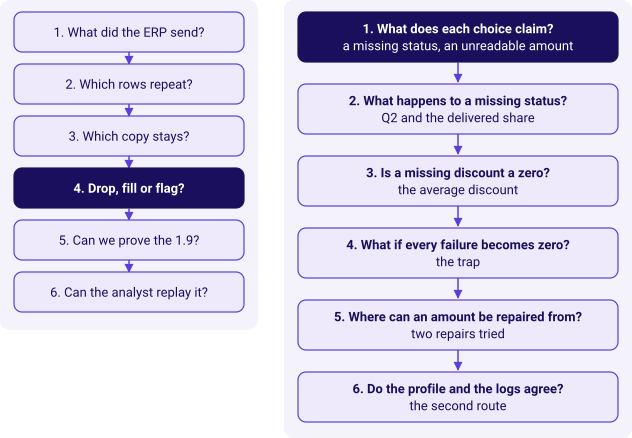

In [2]:
kit.side_by_side(
    kit.ladder(["What did the ERP send?", "Which rows repeat?", "Which copy stays?", "Drop, fill or flag?", "Can we prove the 1.9?", "Can the analyst replay it?"], lit=3, show=False),
    kit.vflow(["1. What does each choice claim?\na missing status, an unreadable amount", "2. What happens to a missing status?\nQ2 and the delivered share", "3. Is a missing discount a zero?\nthe average discount", "4. What if every failure becomes zero?\nthe trap", "5. Where can an amount be repaired from?\ntwo repairs tried", "6. Do the profile and the logs agree?\nthe second route"], lit=0, show=False),
)

## 1. What could the pass do with a missing status or an unreadable amount, and what does each choice claim?

The pass faces two decisions, and each has four options.

| A missing status | What it claims |
|---|---|
| a) Drop the order | the order never happened |
| b) Default it to delivered | the order reached the customer |
| c) Impute it from the customer's last order | the customer's history decides this order's fate |
| d) Keep it and flag it unknown | the order happened and its fate is unknown |

| An amount that does not convert | What it does |
|---|---|
| a) Coerce it to zero | the loop runs and the order is worth nothing |
| b) Reject it to the log | the row leaves revenue, with a line and a reason |
| c) Repair it by reading the text | a person or a parser turns the text into a number |
| d) Repair it from an independent copy | a second source that carries the value supplies it |

missing status,Q2 revenue,Q2 orders,delivered,delivered share
a) drop,"Rs 1,86,98,150",85,57,67.1%
b) default delivered,"Rs 1,87,00,000",86,58,67.4%
c) impute from last order,"Rs 1,87,00,000",86,58,67.4%
d) keep and flag,"Rs 1,87,00,000",86,57,66.3%


unreadable amount,Q1 against the books,what it leaves
a) coerce to zero,"-Rs 1,790",an order at Rs 0 in the clean file
b) reject to the log,"Rs 0 here, the whole order elsewhere",revenue short until repaired
c) repair by reading,see the invented case below,a guess dressed as a value
d) repair from a copy,Rs 0,needs a copy that is independent


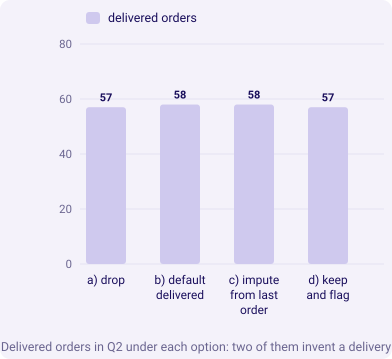

In [3]:
q2 = [r for r in clean if r["quarter"] == "Q2"]
no_status = [r for r in q2 if not r["status"]]
delivered = sum(1 for r in q2 if r["status"] == "delivered")

def last_status(order, rows):
    """The status on the customer's most recent earlier order that carries one."""
    earlier = [r for r in rows if r["customer_id"] == order["customer_id"] and r["status"]
               and r["order_date"] < order["order_date"]]
    return max(earlier, key=lambda r: r["order_date"])["status"] if earlier else ""

imputed = [last_status(o, clean) for o in no_status]
status_opts = [("a) drop", Q(q2, "Q2") - sum(r["amount"] for r in no_status), len(q2) - len(no_status), delivered),
               ("b) default delivered", Q(q2, "Q2"), len(q2), delivered + len(no_status)),
               ("c) impute from last order", Q(q2, "Q2"), len(q2), delivered + imputed.count("delivered")),
               ("d) keep and flag", Q(q2, "Q2"), len(q2), delivered)]
kit.table(["missing status", "Q2 revenue", "Q2 orders", "delivered", "delivered share"],
          [(n, kit.rupees(v), o, d, f"{d / o:.1%}") for n, v, o, d in status_opts],
          caption="The missing status, each option sized on Q2")
coerced_kept = []
seen = {}
for r in raw:                       # coerce first, then keep the first copy, as a hurried pass would
    r2 = dict(r, amount=convert(r["amount"])[0] or 0)
    seen.setdefault(r2["order_id"], r2)
coerced_kept = list(seen.values())
amount_opts = [("a) coerce to zero", kit.rupees(Q(coerced_kept, "Q1") - BOOKS_Q1), "an order at Rs 0 in the clean file"),
               ("b) reject to the log", "Rs 0 here, the whole order elsewhere", "revenue short until repaired"),
               ("c) repair by reading", "see the invented case below", "a guess dressed as a value"),
               ("d) repair from a copy", kit.rupees(Q(clean, "Q1") - BOOKS_Q1), "needs a copy that is independent")]
kit.table(["unreadable amount", "Q1 against the books", "what it leaves"], amount_opts,
          caption="The unreadable amount, each option sized on this export")
kit.columns([n for n, *_ in status_opts], [("delivered orders", [d for *_, d in status_opts])],
            title="Delivered orders in Q2 under each option: two of them invent a delivery")

**The best-fit calls.** For the status, d: revenue is booked value, every order at the price
charged, whatever its status, so the order stays in revenue, and the flag keeps it out of the
delivered count, which stays at 57 of 86. For the amount, b by default and d when an independent
copy exists, which on this file it does: the identity rule already kept the twin that carries the
value. **The facts that would change them:** for the status, a delivery system that can be asked,
which turns the flag into a lookup; for the amount, an independent source carrying the value, which
turns the reject into a repair. A second export cut from the same extract, the same pull of rows out
of the ERP, never counts, since it copies the defect.

## 2. What happens to the order with no status?

**Predict before you run.** Which decision keeps Q2 revenue and the delivered share both honest?
a) drop; b) default delivered; c) impute; d) keep and flag.

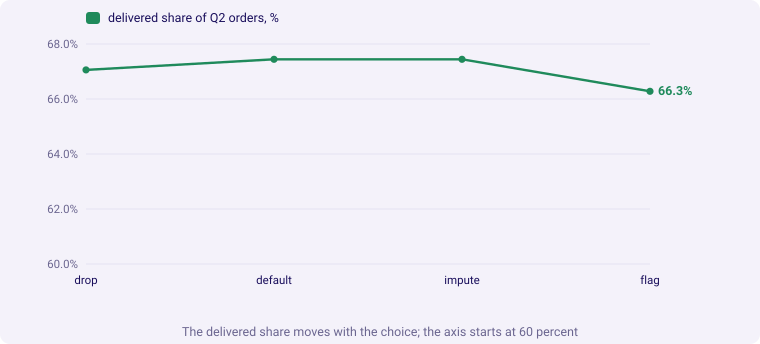

In [4]:
flags = [{"field": "status", "decision": "keep and flag", "why": "booked revenue; its fate is unknown"} for _ in no_status]
kit.line(["drop", "default", "impute", "flag"], [("delivered share of Q2 orders, %", [100 * d / o for _, _, o, d in status_opts], "good")],
         fmt=lambda v: f"{v:.1f}%", lo=60, title="The delivered share moves with the choice; the axis starts at 60 percent")
kit.check("exactly one kept order has no status", len(no_status) == 1)
kit.check("keep and flag leaves Q2 whole", status_opts[3][1] == 18700000, kit.rupees(status_opts[3][1]))
kit.check("the imputation read a status from the same customer's earlier order", all(imputed), f"{len(imputed)} imputed")
kit.check("a default and this imputation each add a delivery nobody recorded",
          status_opts[1][3] > delivered and status_opts[2][3] > delivered)

**What happened.** The answer is d. Dropping removes an order Finance has booked. Defaulting adds a
delivery nobody recorded, and so does the imputation here, because the customer's earlier order was
delivered; each lifts the delivered share from 66.3 to 67.4 percent. Keep and flag leaves Q2 at
Rs 1,87,00,000 and writes one line in the flags log, the list of records kept with a question on
them.

## 3. Is a missing discount a zero?

On Tuesday, the trap was reading a missing discount as zero. Revenue here is the booked amount, so
the discount does not move it; it moves any average discount a report quotes.

**Predict before you run.** The average discount over orders that carry one, against the average
with the missing ones read as zero: how far apart? a) the same; b) a few rupees; c) about 30
percent lower with zeros; d) higher with zeros.

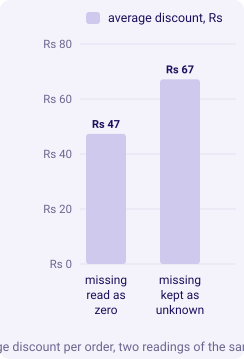

In [5]:
with_disc = [int(r["discount"]) for r in clean if r["discount"] != ""]
discount_unknown = [r["line"] for r in clean if r["discount"] == ""]     # kept, and flagged as unknown
as_zero = with_disc + [0] * len(discount_unknown)
avg_known, avg_zero = sum(with_disc) / len(with_disc), sum(as_zero) / len(as_zero)
kit.columns(["missing read as zero", "missing kept as unknown"], [("average discount, Rs", [avg_zero, avg_known])],
            fmt=lambda v: f"Rs {v:.0f}", title="Average discount per order, two readings of the same file")
kit.check("55 kept orders carry no discount", len(discount_unknown) == 55)
kit.check("zeros pull the average down by over a quarter", avg_zero < 0.75 * avg_known, f"Rs {avg_zero:.0f} against Rs {avg_known:.0f}")

**What happened.** The answer is c. Reading 55 absences as zero pulls the average from about Rs 67 to
about Rs 47. The decision is keep and flag: revenue does not need the field, and any discount
figure is quoted over the orders that carry one, with the count beside it.

## 4. What if every failure is turned into zero?

**The plausible wrong answer.** Chapter 1's first total stopped on a `ValueError` at the one amount
that does not convert, so a hurried analyst writes a helper that turns anything unreadable into
zero, then runs the dedupe everybody reaches for, which removes repeated rows by keeping the first
copy of each order.

In [6]:
def to_int(value):
    try:
        return int(value)
    except ValueError:
        return 0                     # "so the loop does not crash"

coerced = [dict(r, amount=to_int(r["amount"])) for r in raw]
failures = sum(1 for r in coerced if not isinstance(r["amount"], int))
kit.stats([(f"{len(raw) - failures} of {len(raw)}", "amounts convert", "the coerced profile"),
           ("0", "rows in the rejects log", "nothing to explain"),
           (f"{len(coerced_kept)} orders", "in the clean file", "one per order id, all of them numbers")],
          caption="The coerced pass, as it would be reported")

**Why it is wrong.** A zero is a claim that Kalpa sold that order for nothing. Once the unreadable
copy is worth Rs 0 it passes as valid, the identity rule can no longer tell it from its twin, the
first copy wins, and Q1 lands Rs 1,790 short with an order at Rs 0 in a file the note calls clean.
The profile's failure count went from one to zero while nothing was fixed. The check asks whether
a Kalpa order can be worth nothing.

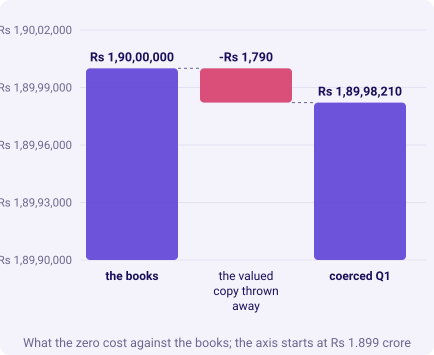

In [7]:
smallest_real = min(r["amount"] for r in clean)
zero_orders = [r for r in coerced_kept if r["amount"] == 0]
kit.check("the coerced pass keeps an order at Rs 0", len(zero_orders) == 1, f"{len(zero_orders)} order")
kit.check("no real order in the export is below Rs 600", smallest_real >= 600, f"the smallest is {kit.rupees(smallest_real)}")
kit.check("the coerced pass misses the books by Rs 1,790", BOOKS_Q1 - Q(coerced_kept, "Q1") == 1790)
kit.bridge(("the books", BOOKS_Q1), [("the valued copy thrown away", -1790)], end_label="coerced Q1",
           lo=18990000, title="What the zero cost against the books; the axis starts at Rs 1.899 crore")

**The fix, and what changed.** The pass's own order: the identity rule first, keeping the copy
whose amount converts, then conversion, with a rejects log for any amount left without a valid
twin. The unreadable copy goes to the set-aside log with its twin named, the twin with the value
stays, the Rs 0 order never exists, and Q1 is back on the books. The profile of the export still
reports one failure, which is the truth about the export; the rejects log after the rule is empty,
which is the truth about the clean file.

## 5. Where can an unreadable amount be repaired from?

Two repairs suggest themselves. The first reads the text as a number, shown here on an invented pair
in which the first copy says `fourteen` and the second `1400`:

In [8]:
WORDS = {"fourteen": 14, "twenty": 20}
invented_pair = [{"order_id": "INV-21", "amount": "fourteen"}, {"order_id": "INV-21", "amount": "1400"}]   # invented
read_as_word = WORDS[invented_pair[0]["amount"]]
kit.table(["repair", "value", "against the twin"], [("read the word", read_as_word, read_as_word - 1400),
                                                    ("take the twin", 1400, 0)], caption="Invented: a word is not an amount")
kit.check("reading the word misses the invented order by Rs 1,386", 1400 - read_as_word == 1386)

repair,value,against the twin
read the word,14,-1386
take the twin,1400,0


The second repair takes the value from the app's JSON feed, a file of orders written as JSON
records that the ERP sent beside the CSV.

**Predict before you run.** For the orders the feed holds, how many amounts agree with the clean
file? a) all 119; b) 118, and the one that differs carries unreadable text; c) about half; d) none.

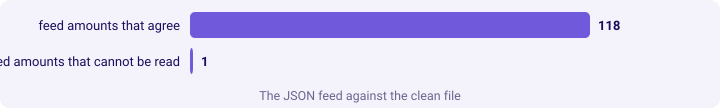

In [9]:
text = (DATA / "C2_W01_D03_orders_STUDENT.json").read_text(encoding="utf-8")
decoder, feed, at = json.JSONDecoder(), [], text.index("{")
while True:
    try:
        record, end = decoder.raw_decode(text, at)
    except json.JSONDecodeError:
        break
    feed.append(record)
    at = text.find("{", end)
    if at == -1:
        break
clean_by_id = {r["order_id"]: r["amount"] for r in clean}
agree = sum(1 for r in feed if convert(r.get("amount"))[0] == clean_by_id.get(r["order_id"]))
unreadable_in_feed = sum(1 for r in feed if convert(r.get("amount"))[0] is None)
kit.bars([("feed amounts that agree", agree), ("feed amounts that cannot be read", unreadable_in_feed)],
         title="The JSON feed against the clean file")
kit.check("the feed agrees on 118 of 119", agree == 118)
kit.check("the one it does not confirm is unreadable in the feed too", unreadable_in_feed == 1)

**What happened.** The answer is b. The feed witnesses what the extract held, never whether a
value is right: it carries the same unreadable text, so it cannot repair it. The CSV's second
extract carried the value, and the identity rule already used it. The rule for the log: repair
only from a source that could not have copied the error, and name the source.

## 6. Do the profile and the logs agree on every defect?

As a second route, the profile counts defects in aggregate while the logs list them row by row, so
the two must agree.

In [10]:
p = profile(clean)
kit.table(["defect", "from the profile of the clean file", "from the logs"],
          [("status missing", len(clean) - p["status"]["present"], len(flags)),
           ("amount that fails", p["amount"]["present"] - p["amount"]["convertible"], len(rejects)),
           ("discount missing", len(clean) - p["discount"]["present"], len(discount_unknown))])
kit.check("the profile and the flags log agree on the status", len(clean) - p["status"]["present"] == len(flags))
kit.check("the profile and the rejects log agree on the amount",
          p["amount"]["present"] - p["amount"]["convertible"] == len(rejects) == 0)
kit.check("the profile and the discount flags agree", len(clean) - p["discount"]["present"] == len(discount_unknown))

defect,from the profile of the clean file,from the logs
status missing,1,1
amount that fails,0,0
discount missing,55,55


**When to switch.** The profile is how you find defects; the log is how you show them. Run the
profile on the clean file at the end of every pass, and a defect that got past the log shows as a
count that disagrees.

Kavya Nair, the senior analyst on the team, checks every number before it leaves.

> **Kavya's review.** "Drop, default, or keep and flag: each is a claim about the business. Write
> the claim beside the decision, and never fill in a money value."

### In the interview: how do you handle missing data, and do you coerce, reject or repair a malformed amount?

**[S] How do you handle missing data?** "Measure it per field, then ask what the absence means,
because an absent discount and an absent status mean different things. Then one of three decisions
with a written reason: drop, fill a stated default, or keep and flag. I size each on the numbers it
moves: here dropping costs Rs 1,850 of booked revenue, a default adds a delivery nobody recorded,
and keep and flag moves nothing and says so. For money I never fill."

**[D] Design. Coerce, reject or repair a malformed amount?** "Reject to a log by default, since a
coerced zero is a false value and hides the defect from every later check. Repair only from an
independent source, and name it. I would switch to repair-by-rule only for a known format issue,
such as a thousands separator, where the rule is exact and tested."

### Depth: can a missing value be dropped without bending a rate?

Statisticians separate values missing completely at random from values whose absence depends on
something, such as discounts left blank only by one channel. Only the first can be dropped without
bending a rate. Imputation, filling a value from other records, belongs to model features with a
column that flags the filled values; for Finance, the answer stays keep and flag.

## So what should the pass do with a value that is missing or cannot be read?

1. For the missing status, dropping the order gives 67.1 percent delivered, a default or an
   imputation 67.4 and keep and flag 66.3; for the unreadable amount, coercing it misses the books by
   Rs 1,790, so the pass rejects it and repairs it only from an independent copy.
2. The order with no status is kept and flagged: Q2 stays at Rs 1,87,00,000, with 57 of 86 orders
   delivered, 66.3 percent.
3. A missing discount stays unknown: read as zeros, the missing values pull the average from about
   Rs 67 over 131 orders to about Rs 47 over 186.
4. Turning every failure into zero makes 201 of 201 amounts convert and empties the rejects log, and
   it leaves one order at Rs 0 and Q1 Rs 1,790 short.
5. An unreadable amount can be repaired only from a source that could not have copied the error, and
   the JSON feed carries the same unreadable text, so it repairs nothing.
6. The profile and the logs agree on every defect: 1 status, 0 amounts and 55 discounts in both.

The missing status is kept and flagged, so Q2 stays at Rs 1,87,00,000 with 57 of 86 orders
delivered, 66.3 percent. The missing discount stays unknown, about Rs 67 over 131 orders and never
Rs 47. An unreadable amount is rejected to the log and repaired only from an independent source,
since the coerced zero would cost Rs 1,790.

In [11]:
kit.check_summary()
print("Next, chapter 5: can we prove to Anand, one cause at a time, that his Rs 1.9 crore is right, "
      "and does Tuesday's finding survive the clean file?")

Next, chapter 5: can we prove to Anand, one cause at a time, that his Rs 1.9 crore is right, and does Tuesday's finding survive the clean file?
